## 1. Imports y Configuración

In [1]:
import os
import sys
import pickle
import glob
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "resilience_comparison")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Importar librerías modulares
parent_dir = os.path.join(BASE_DIR, "scripts", "idroverdi_autoencoder_3")
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from resilience_lib import compute_IRCT_pixel_wise, plot_IRCT_spatial

# Configuración de experimento
N_RUNS = 5  # Número de entrenamientos independientes
SEEDS = [42, 123, 456, 789, 2024]  # Seeds diferentes para reproducibilidad controlada
K_CLUSTERS = 3
LATENT_DIM = 12
EPOCHS = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Número de runs: {N_RUNS}")
print(f"Seeds: {SEEDS}")
print(f"Directorio de plots: {PLOTS_DIR}")

Device: cuda
Número de runs: 5
Seeds: [42, 123, 456, 789, 2024]
Directorio de plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison


## 2. Arquitectura VAE

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, p_drop=0.05):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(256, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    
    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar, z

def vae_loss(x, x_hat, mu, logvar, beta=0.5):
    recon = nn.MSELoss(reduction='mean')(x_hat, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

print("Arquitectura VAE definida")

Arquitectura VAE definida


## 3. Carga de Datos del Experimento 1

In [3]:
print("CARGANDO DATOS DESDE EXPERIMENTO 1")
print("="*80)

# Buscar archivo más reciente
trained_dir = os.path.join(DATA_DIR, "autoencoder_trained_v2")
pattern = os.path.join(trained_dir, "experiment1_clustering_*.pkl")
available_files = glob.glob(pattern)

if not available_files:
    raise FileNotFoundError(f"No se encontraron archivos en: {pattern}")

export_path = max(available_files, key=os.path.getmtime)
print(f"Archivo: {os.path.basename(export_path)}\n")

with open(export_path, "rb") as f:
    exp1_data = pickle.load(f)

# Extraer datos
X_BASE = exp1_data["X_BASE"]
X245 = exp1_data["B245"]
X370 = exp1_data["B370"]
X585 = exp1_data["B585"]
feature_names = exp1_data["feature_names_transformed"]
coords_df = exp1_data["coords_df"]

n_features = X_BASE.shape[1]
n_spatial = len(coords_df)

print(f"Datos cargados:")
print(f"  X_BASE: {X_BASE.shape}")
print(f"  X585: {X585.shape}")
print(f"  Features: {n_features}")
print(f"  Píxeles espaciales: {n_spatial}")
print(f"\n{'='*80}")

CARGANDO DATOS DESDE EXPERIMENTO 1
Archivo: experiment1_clustering_20251209_001834.pkl

Datos cargados:
  X_BASE: (1983, 29)
  X585: (661, 29)
  Features: 29
  Píxeles espaciales: 661



## 4. Función de Entrenamiento VAE

In [4]:
def train_vae_with_seed(X_train, seed, latent_dim=12, epochs=200, lr=0.001, beta=0.5, batch_size=64, verbose=False):
    """
    Entrena VAE con un seed específico para reproducibilidad controlada.
    """
    # Fijar seed
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    # Inicializar modelo
    model = VAE(input_dim=X_train.shape[1], latent_dim=latent_dim, p_drop=0.05).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    # Preparar datos
    X_tensor = torch.FloatTensor(X_train).to(device)
    dataset = torch.utils.data.TensorDataset(X_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch_x,) in loader:
            optimizer.zero_grad()
            x_hat, mu, logvar, z = model(batch_x)
            loss, recon, kl = vae_loss(batch_x, x_hat, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        scheduler.step(avg_loss)
        
        if verbose and (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    
    # Encoding final
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_train).to(device)
        _, mu, _, _ = model(X_tensor)
        Z_train = mu.cpu().numpy()
    
    return model, Z_train

print("Función de entrenamiento definida")

Función de entrenamiento definida


## 5. Función de Clustering KMeans

In [5]:
def apply_kmeans_clustering(Z, k=3, seed=42):
    """
    Aplica KMeans sobre representación latente Z.
    """
    scaler = StandardScaler()
    Z_scaled = scaler.fit_transform(Z)
    
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=50, max_iter=500)
    labels = kmeans.fit_predict(Z_scaled)
    
    return labels, kmeans.cluster_centers_, scaler

print("Función de clustering definida")

Función de clustering definida


## 6. Pipeline de Múltiples Entrenamientos

In [6]:
# Almacenar resultados de cada run
RUNS_RESULTS = []

print(f"EJECUTANDO {N_RUNS} ENTRENAMIENTOS INDEPENDIENTES")
print("="*80)

for run_id, seed in enumerate(SEEDS[:N_RUNS], start=1):
    print(f"\nRUN {run_id}/{N_RUNS} (seed={seed})")
    print("-"*60)
    
    run_result = {
        'run_id': run_id,
        'seed': seed
    }
    
    # 1. Entrenar VAE en BASE
    print(f"  Entrenando VAE_BASE...")
    vae_base, Z_base = train_vae_with_seed(
        X_BASE[:n_spatial],  # Solo primeros n_spatial puntos
        seed=seed,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        verbose=False
    )
    
    # 2. Entrenar VAE en T585
    print(f"  Entrenando VAE_T585...")
    vae_t585, Z_t585 = train_vae_with_seed(
        X585[:n_spatial],
        seed=seed,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        verbose=False
    )
    
    # 3. Clustering en BASE
    print(f"  Clustering KMeans (k={K_CLUSTERS})...")
    labels_base, centroids_base, scaler_base = apply_kmeans_clustering(Z_base, k=K_CLUSTERS, seed=seed)
    
    # 4. Calcular IRCT
    print(f"  Calculando IRCT...")
    irct_results = compute_IRCT_pixel_wise(
        model=vae_t585,
        X_base_orig=X_BASE[:n_spatial],
        X_base_norm=X_BASE[:n_spatial],
        X_future_orig=X585[:n_spatial],
        X_future_norm=X585[:n_spatial],
        z_base_scaled=Z_base,
        z_future_scaled=Z_t585,
        centroids_base=centroids_base,
        labels_base=labels_base,
        h2_base=None,
        h2_future=None,
        device=str(device),
        weights={'w_a': 0.25, 'w_d': 0.25, 'w_c': 0.20, 'w_e': 0.15, 'w_h': 0.15},
        recon_use_normalized=True,
        inverse_transform=None,
        softmax_tau=1.0
    )
    
    # 5. Guardar resultados
    irt_scores = 100.0 * irct_results['IRCT']
    
    run_result.update({
        'vae_base': vae_base,
        'vae_t585': vae_t585,
        'Z_base': Z_base,
        'Z_t585': Z_t585,
        'labels_base': labels_base,
        'centroids_base': centroids_base,
        'irt_scores': irt_scores,
        'irct_components': irct_results
    })
    
    RUNS_RESULTS.append(run_result)
    
    # Estadísticas del IRCT
    print(f"  IRCT - Media: {irt_scores.mean():.2f}")
    print(f"  IRCT - Std: {irt_scores.std():.2f}")
    print(f"  IRCT - Rango: [{irt_scores.min():.2f}, {irt_scores.max():.2f}]")

print(f"\n{'='*80}")
print(f"✓ {N_RUNS} entrenamientos completados")
print(f"  Resultados almacenados en RUNS_RESULTS")
print("="*80)

EJECUTANDO 5 ENTRENAMIENTOS INDEPENDIENTES

RUN 1/5 (seed=42)
------------------------------------------------------------
  Entrenando VAE_BASE...


  Entrenando VAE_T585...
  Clustering KMeans (k=3)...
  Calculando IRCT...

[DEBUG compute_reconstruction_anomaly]
  model type: VAE
  X_orig shape: (661, 29)
  X_normalized shape: (661, 29)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expansion] Retornando 661 valores únicos de 661 píxeles
  IRCT - Media: 41.31
  IRCT - Std: 16.79
  IRCT - Rango: [0.00, 72.92]

RUN 2/5 (seed=123)
------------------------------------------------------------
  Entrenando VAE_BASE...
  Entrenando VAE_T585...
  Clustering KMeans (k=3)...
  Calculando IRCT...

[DEBUG compute_reconstruction_anomaly]
  model type: VAE
  X_orig shape: (661, 29)
  X_normalized shape: (661, 29)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expansion] Retornando 661 valores únicos de 661 píxeles
  IRCT - Media: 40.23
  IRCT - Std: 15.70
  IRCT - Rango: [0.00, 71.96]

RUN 3/5 (seed=456)
------------

## 7. Análisis de Correlación entre Runs

In [7]:
print("ANÁLISIS DE CORRELACIÓN ENTRE RUNS")
print("="*80)

# Matriz de correlaciones Pearson y Spearman
n_runs = len(RUNS_RESULTS)
corr_pearson = np.zeros((n_runs, n_runs))
corr_spearman = np.zeros((n_runs, n_runs))

for i in range(n_runs):
    for j in range(n_runs):
        irt_i = RUNS_RESULTS[i]['irt_scores']
        irt_j = RUNS_RESULTS[j]['irt_scores']
        
        # Pearson (correlación lineal)
        r_pearson, _ = pearsonr(irt_i, irt_j)
        corr_pearson[i, j] = r_pearson
        
        # Spearman (correlación de ranking)
        r_spearman, _ = spearmanr(irt_i, irt_j)
        corr_spearman[i, j] = r_spearman

# Estadísticas (excluyendo diagonal)
mask = ~np.eye(n_runs, dtype=bool)
pearson_offdiag = corr_pearson[mask]
spearman_offdiag = corr_spearman[mask]

print("\n1. CORRELACIÓN PEARSON (valores IRCT)")
print(f"  Media: {pearson_offdiag.mean():.4f}")
print(f"  Std: {pearson_offdiag.std():.4f}")
print(f"  Min: {pearson_offdiag.min():.4f}")
print(f"  Max: {pearson_offdiag.max():.4f}")

print("\n2. CORRELACIÓN SPEARMAN (ranking IRCT)")
print(f"  Media: {spearman_offdiag.mean():.4f}")
print(f"  Std: {spearman_offdiag.std():.4f}")
print(f"  Min: {spearman_offdiag.min():.4f}")
print(f"  Max: {spearman_offdiag.max():.4f}")

# Interpretación
print("\n3. INTERPRETACIÓN:")
if pearson_offdiag.mean() > 0.80:
    print("  ✓ ALTA ESTABILIDAD: Correlación Pearson > 0.80")
    print("    → Los valores absolutos del IRCT son consistentes")
elif pearson_offdiag.mean() > 0.60:
    print("  ≈ ESTABILIDAD MODERADA: Correlación Pearson 0.60-0.80")
    print("    → Variabilidad moderada en valores absolutos")
else:
    print("  ✗ BAJA ESTABILIDAD: Correlación Pearson < 0.60")
    print("    → Alta variabilidad, revisar hiperparámetros")

if spearman_offdiag.mean() > 0.85:
    print("  ✓ RANKING CONSISTENTE: Spearman > 0.85")
    print("    → El ordenamiento de zonas por resiliencia es estable")
elif spearman_offdiag.mean() > 0.70:
    print("  ≈ RANKING MODERADO: Spearman 0.70-0.85")
    print("    → Algunas zonas cambian de posición relativa")
else:
    print("  ✗ RANKING INESTABLE: Spearman < 0.70")
    print("    → El ordenamiento cambia significativamente")

print("\n" + "="*80)

ANÁLISIS DE CORRELACIÓN ENTRE RUNS

1. CORRELACIÓN PEARSON (valores IRCT)
  Media: 0.4774
  Std: 0.1426
  Min: 0.3432
  Max: 0.7123

2. CORRELACIÓN SPEARMAN (ranking IRCT)
  Media: 0.4457
  Std: 0.1462
  Min: 0.2651
  Max: 0.6843

3. INTERPRETACIÓN:
  ✗ BAJA ESTABILIDAD: Correlación Pearson < 0.60
    → Alta variabilidad, revisar hiperparámetros
  ✗ RANKING INESTABLE: Spearman < 0.70
    → El ordenamiento cambia significativamente



## 8. Visualización de Matrices de Correlación

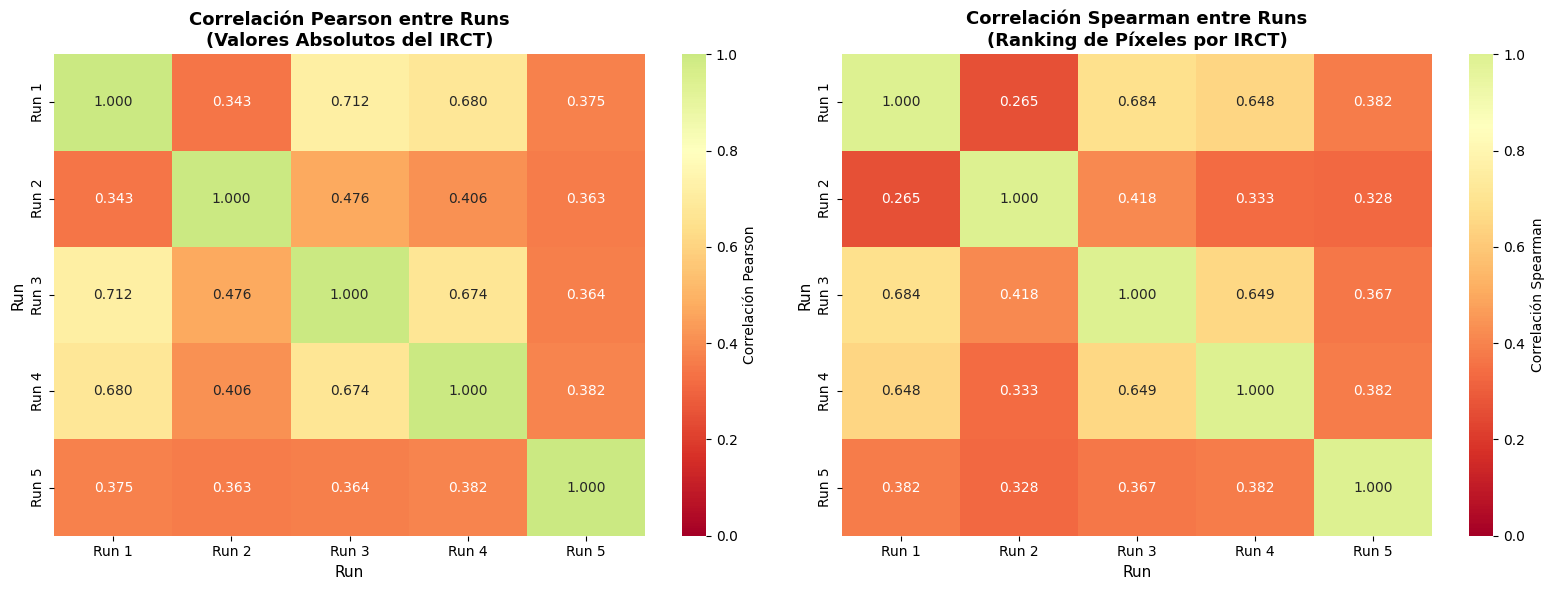

Matrices de correlación guardadas


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap Pearson
ax1 = axes[0]
sns.heatmap(corr_pearson, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, center=0.8, ax=ax1,
            xticklabels=[f"Run {i+1}" for i in range(n_runs)],
            yticklabels=[f"Run {i+1}" for i in range(n_runs)],
            cbar_kws={'label': 'Correlación Pearson'})
ax1.set_title('Correlación Pearson entre Runs\n(Valores Absolutos del IRCT)', 
             fontsize=13, fontweight='bold')
ax1.set_xlabel('Run', fontsize=11)
ax1.set_ylabel('Run', fontsize=11)

# Heatmap Spearman
ax2 = axes[1]
sns.heatmap(corr_spearman, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, center=0.85, ax=ax2,
            xticklabels=[f"Run {i+1}" for i in range(n_runs)],
            yticklabels=[f"Run {i+1}" for i in range(n_runs)],
            cbar_kws={'label': 'Correlación Spearman'})
ax2.set_title('Correlación Spearman entre Runs\n(Ranking de Píxeles por IRCT)', 
             fontsize=13, fontweight='bold')
ax2.set_xlabel('Run', fontsize=11)
ax2.set_ylabel('Run', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "reproducibility_correlation_matrices.png"), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Matrices de correlación guardadas")

## 9. Análisis de Variabilidad Espacial del IRCT

In [9]:
print("ANÁLISIS DE VARIABILIDAD ESPACIAL DEL IRCT")
print("="*80)

# Construir matriz: píxeles × runs
irt_matrix = np.column_stack([r['irt_scores'] for r in RUNS_RESULTS])

# Estadísticas por píxel
irt_mean_per_pixel = irt_matrix.mean(axis=1)
irt_std_per_pixel = irt_matrix.std(axis=1)
irt_cv_per_pixel = irt_std_per_pixel / (irt_mean_per_pixel + 1e-8)  # Evitar división por cero

# Estadísticas globales
print(f"\n1. ESTADÍSTICAS DEL IRCT PROMEDIO (across runs):")
print(f"  Media global: {irt_mean_per_pixel.mean():.2f}")
print(f"  Std global: {irt_mean_per_pixel.std():.2f}")
print(f"  Rango: [{irt_mean_per_pixel.min():.2f}, {irt_mean_per_pixel.max():.2f}]")

print(f"\n2. VARIABILIDAD ENTRE RUNS (por píxel):")
print(f"  Std promedio entre runs: {irt_std_per_pixel.mean():.2f}")
print(f"  CV promedio entre runs: {irt_cv_per_pixel.mean():.4f} ({100*irt_cv_per_pixel.mean():.2f}%)")
print(f"  CV máximo: {irt_cv_per_pixel.max():.4f} ({100*irt_cv_per_pixel.max():.2f}%)")

# Interpretación
cv_mean = irt_cv_per_pixel.mean()
print(f"\n3. INTERPRETACIÓN:")
if cv_mean < 0.10:
    print(f"  ✓ BAJA VARIABILIDAD: CV = {100*cv_mean:.1f}% < 10%")
    print("    → El IRCT es muy estable entre entrenamientos")
elif cv_mean < 0.15:
    print(f"  ≈ VARIABILIDAD MODERADA: CV = {100*cv_mean:.1f}% (10-15%)")
    print("    → Variabilidad aceptable, típica de modelos estocásticos")
else:
    print(f"  ✗ ALTA VARIABILIDAD: CV = {100*cv_mean:.1f}% > 15%")
    print("    → Revisar convergencia del entrenamiento o aumentar epochs")

# Identificar píxeles con alta/baja variabilidad
high_var_pixels = np.argsort(irt_cv_per_pixel)[-10:]  # Top 10 más variables
low_var_pixels = np.argsort(irt_cv_per_pixel)[:10]    # Top 10 más estables

print(f"\n4. PÍXELES CON MAYOR VARIABILIDAD:")
for idx in high_var_pixels[:5]:
    lat, lon = coords_df.iloc[idx][['lat', 'lon']]
    print(f"  Píxel {idx}: lat={lat:.4f}, lon={lon:.4f}, CV={100*irt_cv_per_pixel[idx]:.1f}%, IRCT_mean={irt_mean_per_pixel[idx]:.1f}")

print(f"\n5. PÍXELES MÁS ESTABLES:")
for idx in low_var_pixels[:5]:
    lat, lon = coords_df.iloc[idx][['lat', 'lon']]
    print(f"  Píxel {idx}: lat={lat:.4f}, lon={lon:.4f}, CV={100*irt_cv_per_pixel[idx]:.1f}%, IRCT_mean={irt_mean_per_pixel[idx]:.1f}")

print("\n" + "="*80)

ANÁLISIS DE VARIABILIDAD ESPACIAL DEL IRCT

1. ESTADÍSTICAS DEL IRCT PROMEDIO (across runs):
  Media global: 40.95
  Std global: 12.07
  Rango: [4.37, 68.41]

2. VARIABILIDAD ENTRE RUNS (por píxel):
  Std promedio entre runs: 9.62
  CV promedio entre runs: 0.2634 (26.34%)
  CV máximo: 1.0274 (102.74%)

3. INTERPRETACIÓN:
  ✗ ALTA VARIABILIDAD: CV = 26.3% > 15%
    → Revisar convergencia del entrenamiento o aumentar epochs

4. PÍXELES CON MAYOR VARIABILIDAD:
  Píxel 283: lat=-32.4750, lon=-70.7250, CV=87.3%, IRCT_mean=20.1
  Píxel 372: lat=-32.5750, lon=-70.0750, CV=87.8%, IRCT_mean=30.2
  Píxel 142: lat=-32.4250, lon=-70.0250, CV=89.9%, IRCT_mean=9.2
  Píxel 327: lat=-32.5750, lon=-70.0250, CV=90.6%, IRCT_mean=11.9
  Píxel 312: lat=-32.4750, lon=-70.1250, CV=90.7%, IRCT_mean=15.9

5. PÍXELES MÁS ESTABLES:
  Píxel 645: lat=-32.4750, lon=-70.4750, CV=4.0%, IRCT_mean=57.4
  Píxel 226: lat=-32.8750, lon=-70.7250, CV=4.3%, IRCT_mean=64.6
  Píxel 643: lat=-32.5750, lon=-70.5250, CV=4.3%, IRC

## 10. Mapas de IRCT Individual por Run (con plot_IRCT_spatial)

VISUALIZACIÓN ESPACIAL: IRCT DE CADA RUN INDIVIDUAL
Rango global del IRCT: [0.00, 79.69]


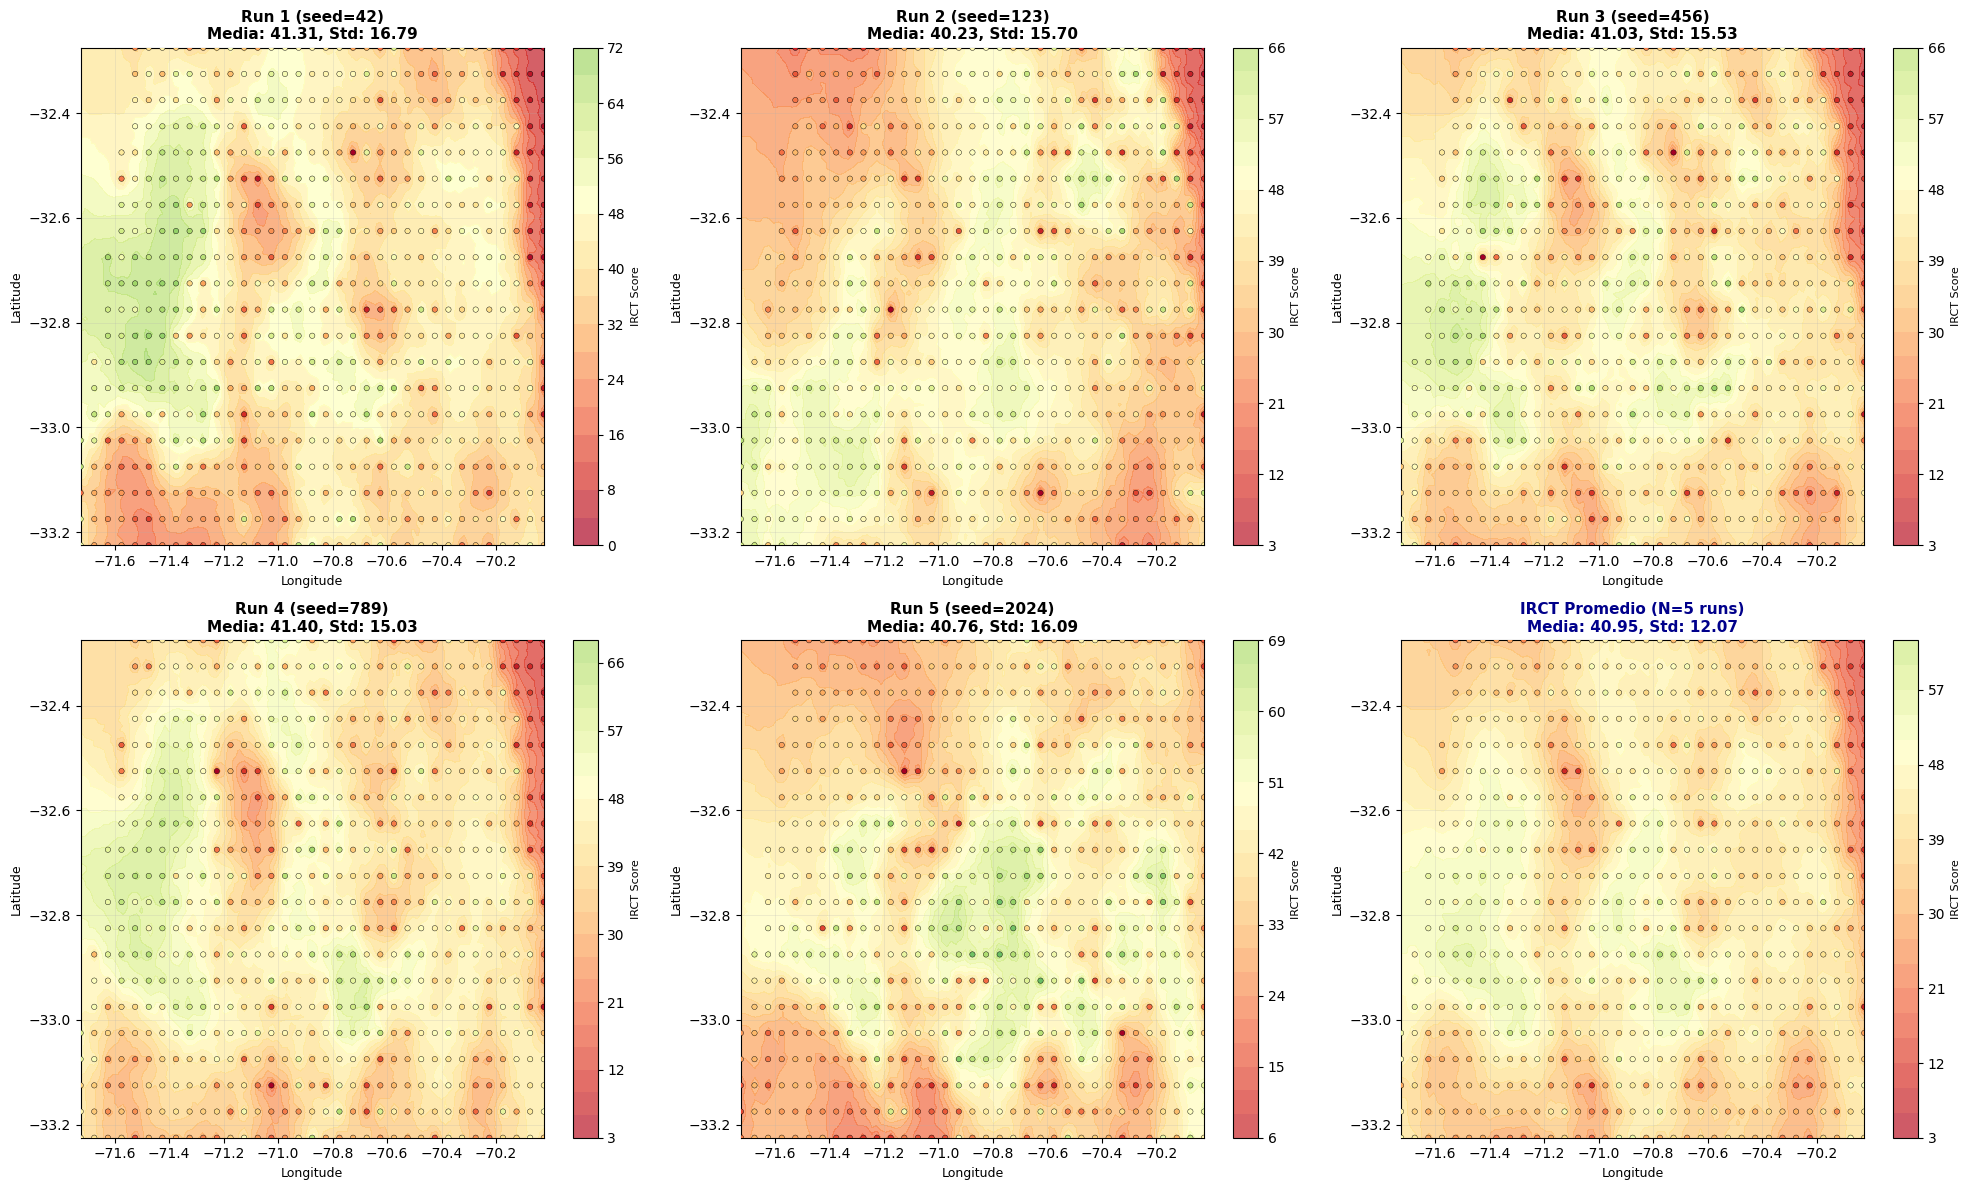


Mapas individuales con interpolación KNN guardados


In [10]:
print("VISUALIZACIÓN ESPACIAL: IRCT DE CADA RUN INDIVIDUAL")
print("="*80)

# Calcular escala común para comparación
vmin_global = min([r['irt_scores'].min() for r in RUNS_RESULTS])
vmax_global = max([r['irt_scores'].max() for r in RUNS_RESULTS])

print(f"Rango global del IRCT: [{vmin_global:.2f}, {vmax_global:.2f}]")

# Crear figura con subplots para todos los runs
fig = plt.figure(figsize=(20, 12))

for idx, run_result in enumerate(RUNS_RESULTS, start=1):
    ax = plt.subplot(2, 3, idx)
    
    irt_scores = run_result['irt_scores']
    
    # Preparar dict compatible con plot_IRCT_spatial
    irct_dict = {'IRCT': irt_scores / 100.0}  # Normalizar a [0, 1]
    
    # Usar plot_IRCT_spatial de resilience_lib
    try:
        from resilience_lib import plot_IRCT_spatial
        
        # Plotear con la función de la librería (sin crear nueva figura)
        plt.sca(ax)
        
        # Llamar a la función manualmente sin crear nueva figura
        from sklearn.neighbors import KNeighborsRegressor
        
        lats = coords_df['lat'].values
        lons = coords_df['lon'].values
        values = irt_scores
        
        # Interpolación KNN
        X = np.column_stack([lons, lats])
        knn = KNeighborsRegressor(n_neighbors=15, weights='distance')
        knn.fit(X, values)
        
        # Grilla
        lon_min, lon_max = lons.min(), lons.max()
        lat_min, lat_max = lats.min(), lats.max()
        lon_grid = np.linspace(lon_min, lon_max, 100)
        lat_grid = np.linspace(lat_min, lat_max, 100)
        LON, LAT = np.meshgrid(lon_grid, lat_grid)
        grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
        Z_pred = knn.predict(grid_points).reshape(LON.shape)
        
        # Plotear
        im = ax.contourf(LON, LAT, Z_pred, levels=20, cmap='RdYlGn', 
                        vmin=0, vmax=100, alpha=0.7)
        ax.scatter(lons, lats, c=values, cmap='RdYlGn', s=15, 
                  edgecolors='black', linewidths=0.3, vmin=0, vmax=100, zorder=5)
        
        ax.set_title(f"Run {run_result['run_id']} (seed={run_result['seed']})\n"
                    f"Media: {irt_scores.mean():.2f}, Std: {irt_scores.std():.2f}", 
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=9)
        ax.set_ylabel('Latitude', fontsize=9)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('IRCT Score', fontsize=8)
        
    except ImportError:
        # Fallback a scatter simple si falla import
        ax.scatter(lons, lats, c=irt_scores, cmap='RdYlGn', s=50, 
                  alpha=0.8, edgecolors='black', linewidths=0.3, vmin=0, vmax=100)
        ax.set_title(f"Run {run_result['run_id']} (seed={run_result['seed']})", 
                    fontsize=11, fontweight='bold')

# Panel final: IRCT Promedio
ax_mean = plt.subplot(2, 3, 6)

X = np.column_stack([coords_df['lon'].values, coords_df['lat'].values])
knn = KNeighborsRegressor(n_neighbors=15, weights='distance')
knn.fit(X, irt_mean_per_pixel)

lon_grid = np.linspace(coords_df['lon'].min(), coords_df['lon'].max(), 100)
lat_grid = np.linspace(coords_df['lat'].min(), coords_df['lat'].max(), 100)
LON, LAT = np.meshgrid(lon_grid, lat_grid)
grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
Z_pred = knn.predict(grid_points).reshape(LON.shape)

im_mean = ax_mean.contourf(LON, LAT, Z_pred, levels=20, cmap='RdYlGn', 
                           vmin=0, vmax=100, alpha=0.7)
ax_mean.scatter(coords_df['lon'], coords_df['lat'], c=irt_mean_per_pixel, 
               cmap='RdYlGn', s=15, edgecolors='black', linewidths=0.3, 
               vmin=0, vmax=100, zorder=5)

ax_mean.set_title(f'IRCT Promedio (N={N_RUNS} runs)\n'
                 f'Media: {irt_mean_per_pixel.mean():.2f}, Std: {irt_mean_per_pixel.std():.2f}', 
                 fontsize=11, fontweight='bold', color='darkblue')
ax_mean.set_xlabel('Longitude', fontsize=9)
ax_mean.set_ylabel('Latitude', fontsize=9)
ax_mean.grid(True, alpha=0.3, linewidth=0.5)

cbar_mean = plt.colorbar(im_mean, ax=ax_mean)
cbar_mean.set_label('IRCT Score', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "reproducibility_irt_individual_runs_knn.png"), 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMapas individuales con interpolación KNN guardados")
print("="*80)

## 11. Mapas de IRCT: Media y Variabilidad

## 12. Comparación Diferencial: IRCT Run-i vs IRCT Promedio (con KNN)

ANÁLISIS DIFERENCIAL: DESVIACIONES RESPECTO AL IRCT PROMEDIO
Rango de diferencias: [-43.51, 43.51]


Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison/reproducibility_irt_differences_knn.png


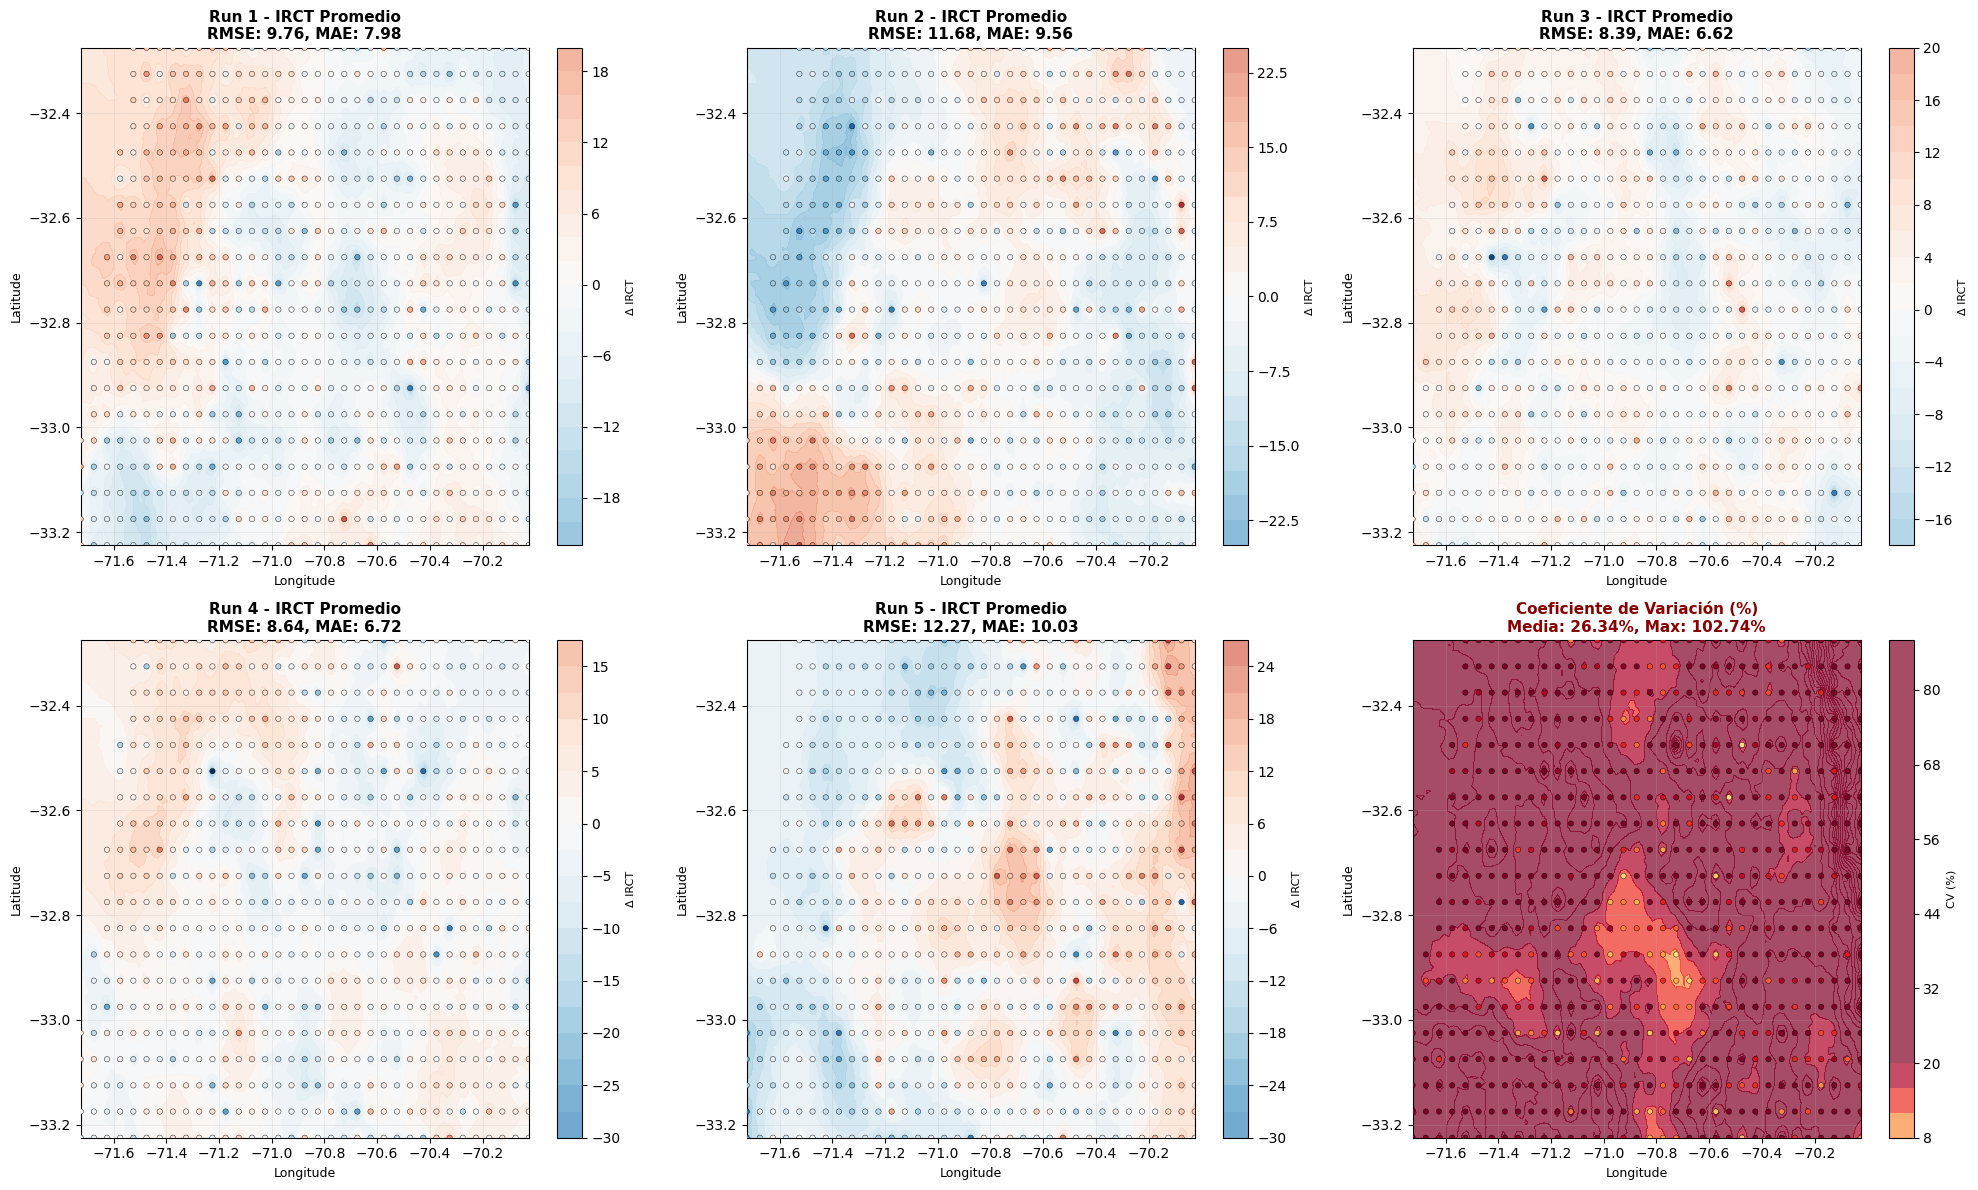


Mapas de diferencias con interpolación KNN guardados


In [11]:
print("ANÁLISIS DIFERENCIAL: DESVIACIONES RESPECTO AL IRCT PROMEDIO")
print("="*80)

from sklearn.neighbors import KNeighborsRegressor

lats = coords_df['lat'].values
lons = coords_df['lon'].values

# Calcular escala simétrica para diferencias
max_diff = max([np.abs(r['irt_scores'] - irt_mean_per_pixel).max() for r in RUNS_RESULTS])
vmin_diff = -max_diff
vmax_diff = max_diff

print(f"Rango de diferencias: [{vmin_diff:.2f}, {vmax_diff:.2f}]")

# Crear figura
fig = plt.figure(figsize=(20, 12))

for idx, run_result in enumerate(RUNS_RESULTS, start=1):
    ax = plt.subplot(2, 3, idx)
    
    irt_diff = run_result['irt_scores'] - irt_mean_per_pixel
    
    # Interpolación KNN para diferencias
    X = np.column_stack([lons, lats])
    knn = KNeighborsRegressor(n_neighbors=15, weights='distance')
    knn.fit(X, irt_diff)
    
    # Grilla
    lon_grid = np.linspace(lons.min(), lons.max(), 100)
    lat_grid = np.linspace(lats.min(), lats.max(), 100)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)
    grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
    Z_pred = knn.predict(grid_points).reshape(LON.shape)
    
    # Plotear
    im = ax.contourf(LON, LAT, Z_pred, levels=20, cmap='RdBu_r', 
                    vmin=vmin_diff, vmax=vmax_diff, alpha=0.7)
    ax.scatter(lons, lats, c=irt_diff, cmap='RdBu_r', s=15, 
              edgecolors='black', linewidths=0.3, vmin=vmin_diff, vmax=vmax_diff, zorder=5)
    
    rmse = np.sqrt(np.mean(irt_diff**2))
    mae = np.mean(np.abs(irt_diff))
    
    ax.set_title(f"Run {run_result['run_id']} - IRCT Promedio\n"
                f"RMSE: {rmse:.2f}, MAE: {mae:.2f}", 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Δ IRCT', fontsize=8)

# Panel final: Mapa de estabilidad (CV)
ax_cv = plt.subplot(2, 3, 6)

# Interpolación KNN para CV
knn_cv = KNeighborsRegressor(n_neighbors=15, weights='distance')
knn_cv.fit(X, 100*irt_cv_per_pixel)
Z_cv = knn_cv.predict(grid_points).reshape(LON.shape)

im_cv = ax_cv.contourf(LON, LAT, Z_cv, levels=20, cmap='YlOrRd', 
                      vmin=0, vmax=20, alpha=0.7)
ax_cv.scatter(lons, lats, c=100*irt_cv_per_pixel, cmap='YlOrRd', s=15, 
             edgecolors='black', linewidths=0.3, vmin=0, vmax=20, zorder=5)

ax_cv.set_title(f'Coeficiente de Variación (%)\n'
               f'Media: {100*irt_cv_per_pixel.mean():.2f}%, Max: {100*irt_cv_per_pixel.max():.2f}%', 
               fontsize=11, fontweight='bold', color='darkred')
ax_cv.set_xlabel('Longitude', fontsize=9)
ax_cv.set_ylabel('Latitude', fontsize=9)
ax_cv.grid(True, alpha=0.3, linewidth=0.5)

cbar_cv = plt.colorbar(im_cv, ax=ax_cv)
cbar_cv.set_label('CV (%)', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "reproducibility_irt_differences_knn.png"), 
            dpi=300, bbox_inches='tight')
print("Guardado en:", os.path.join(PLOTS_DIR, "reproducibility_irt_differences_knn.png"))
plt.show()

print(f"\nMapas de diferencias con interpolación KNN guardados")
print("="*80)

Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison/reproducibility_spatial_variability.png


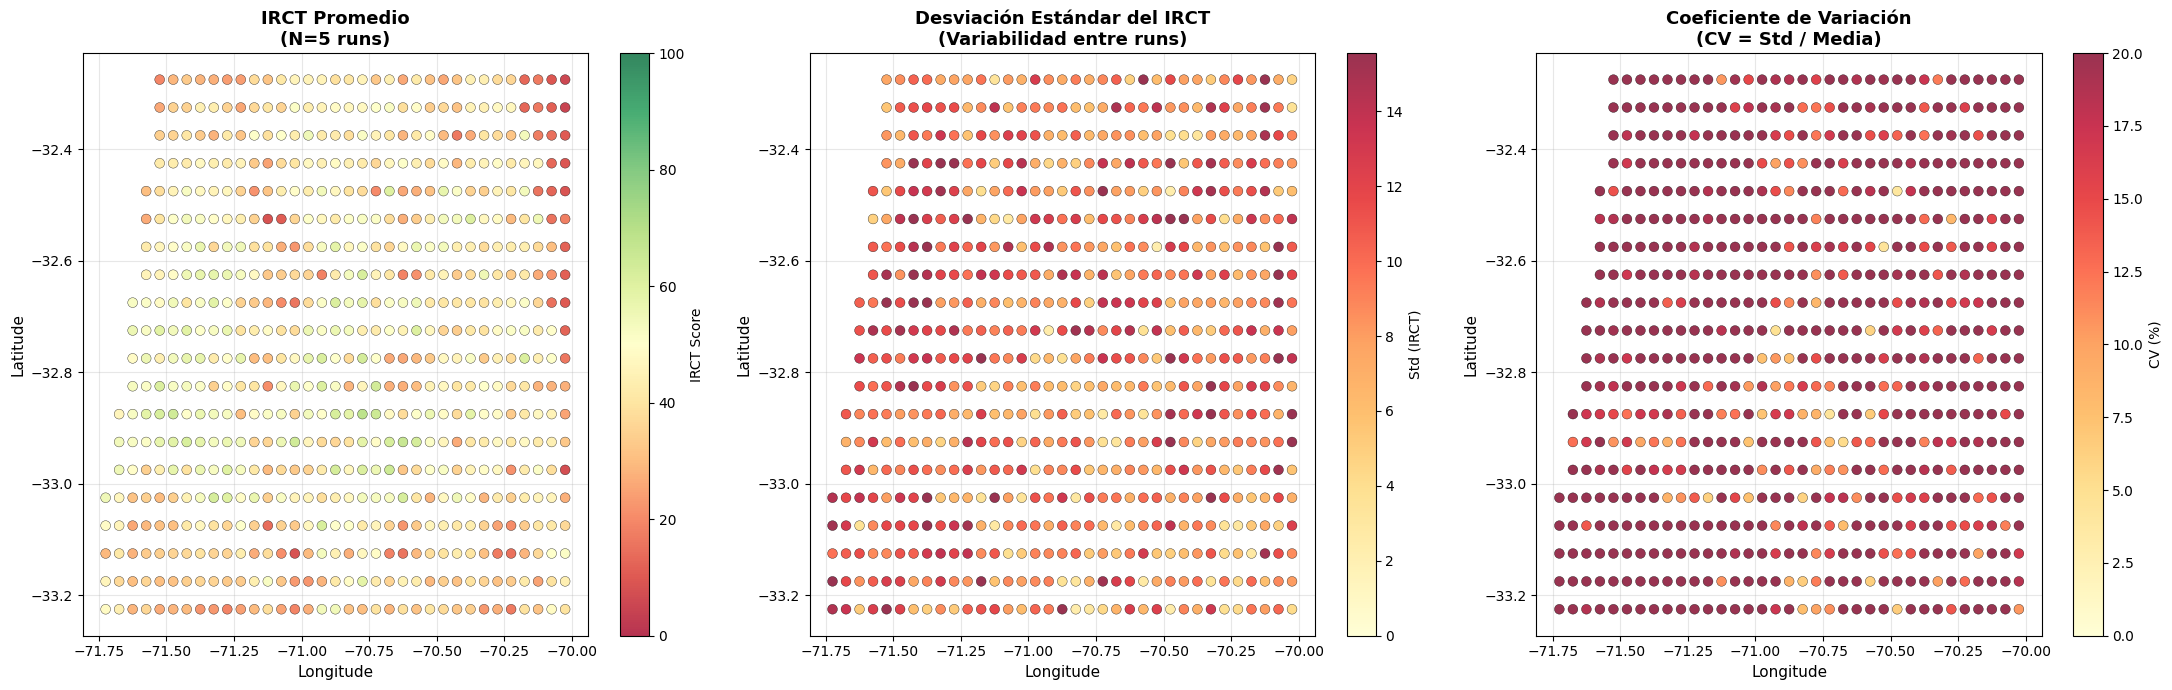

Mapas de variabilidad espacial guardados


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

lats = coords_df['lat'].values
lons = coords_df['lon'].values

# Panel 1: IRCT Promedio
ax1 = axes[0]
scatter1 = ax1.scatter(lons, lats, c=irt_mean_per_pixel, cmap='RdYlGn', 
                      s=50, alpha=0.8, edgecolors='black', linewidths=0.3,
                      vmin=0, vmax=100)
ax1.set_title(f'IRCT Promedio\n(N={N_RUNS} runs)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('IRCT Score', fontsize=10)

# Panel 2: Desviación Estándar
ax2 = axes[1]
scatter2 = ax2.scatter(lons, lats, c=irt_std_per_pixel, cmap='YlOrRd', 
                      s=50, alpha=0.8, edgecolors='black', linewidths=0.3,
                      vmin=0, vmax=np.percentile(irt_std_per_pixel, 95))
ax2.set_title(f'Desviación Estándar del IRCT\n(Variabilidad entre runs)', 
             fontsize=13, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Std (IRCT)', fontsize=10)

# Panel 3: Coeficiente de Variación
ax3 = axes[2]
scatter3 = ax3.scatter(lons, lats, c=100*irt_cv_per_pixel, cmap='YlOrRd', 
                      s=50, alpha=0.8, edgecolors='black', linewidths=0.3,
                      vmin=0, vmax=20)  # Máximo 20%
ax3.set_title(f'Coeficiente de Variación\n(CV = Std / Media)', 
             fontsize=13, fontweight='bold')
ax3.set_xlabel('Longitude', fontsize=11)
ax3.set_ylabel('Latitude', fontsize=11)
ax3.grid(True, alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label('CV (%)', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "reproducibility_spatial_variability.png"), 
            dpi=300, bbox_inches='tight')
print("Guardado en:", os.path.join(PLOTS_DIR, "reproducibility_spatial_variability.png"))
plt.show()

print("Mapas de variabilidad espacial guardados")

## 13. Distribuciones de IRCT por Run

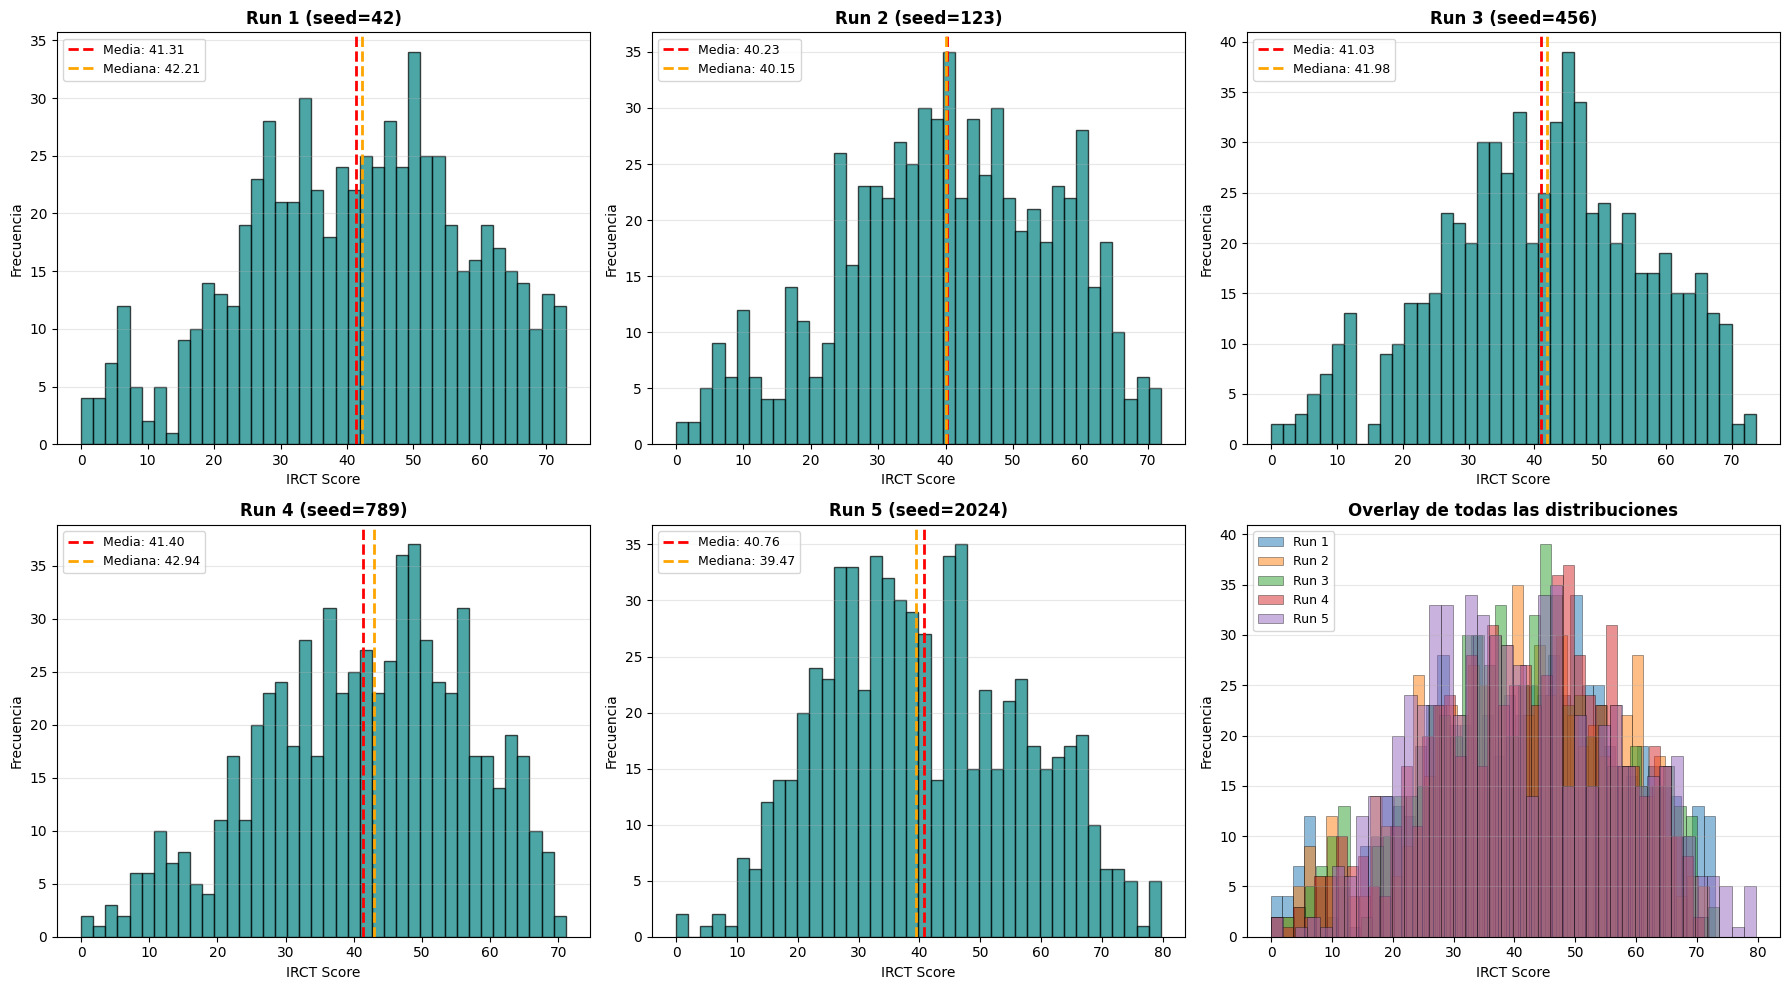

Distribuciones de IRCT por run guardadas


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, run_result in enumerate(RUNS_RESULTS):
    ax = axes[idx]
    irt_scores = run_result['irt_scores']
    
    ax.hist(irt_scores, bins=40, alpha=0.7, color='teal', edgecolor='black')
    ax.axvline(irt_scores.mean(), color='red', linestyle='--', linewidth=2, 
              label=f'Media: {irt_scores.mean():.2f}')
    ax.axvline(np.median(irt_scores), color='orange', linestyle='--', linewidth=2, 
              label=f'Mediana: {np.median(irt_scores):.2f}')
    
    ax.set_title(f"Run {run_result['run_id']} (seed={run_result['seed']})", 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('IRCT Score', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Panel de resumen (último subplot)
ax_summary = axes[-1]
for run_result in RUNS_RESULTS:
    ax_summary.hist(run_result['irt_scores'], bins=40, alpha=0.5, 
                   label=f"Run {run_result['run_id']}", edgecolor='black', linewidth=0.5)

ax_summary.set_title('Overlay de todas las distribuciones', 
                    fontsize=12, fontweight='bold')
ax_summary.set_xlabel('IRCT Score', fontsize=10)
ax_summary.set_ylabel('Frecuencia', fontsize=10)
ax_summary.legend(loc='upper left', fontsize=9)
ax_summary.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "reproducibility_irt_distributions.png"), 
            dpi=300, bbox_inches='tight')
plt.show()

print("Distribuciones de IRCT por run guardadas")

## 14. Consistencia de Clustering entre Runs

ANÁLISIS DE CONSISTENCIA DE CLUSTERING

1. ADJUSTED RAND INDEX (ARI) entre clustering de runs:
  Media: 0.4583
  Std: 0.2497
  Min: 0.1371
  Max: 0.7551

2. INTERPRETACIÓN:
  ✗ CLUSTERING INESTABLE: ARI = 0.458 < 0.50
    → Alta variabilidad en la estructura de clusters


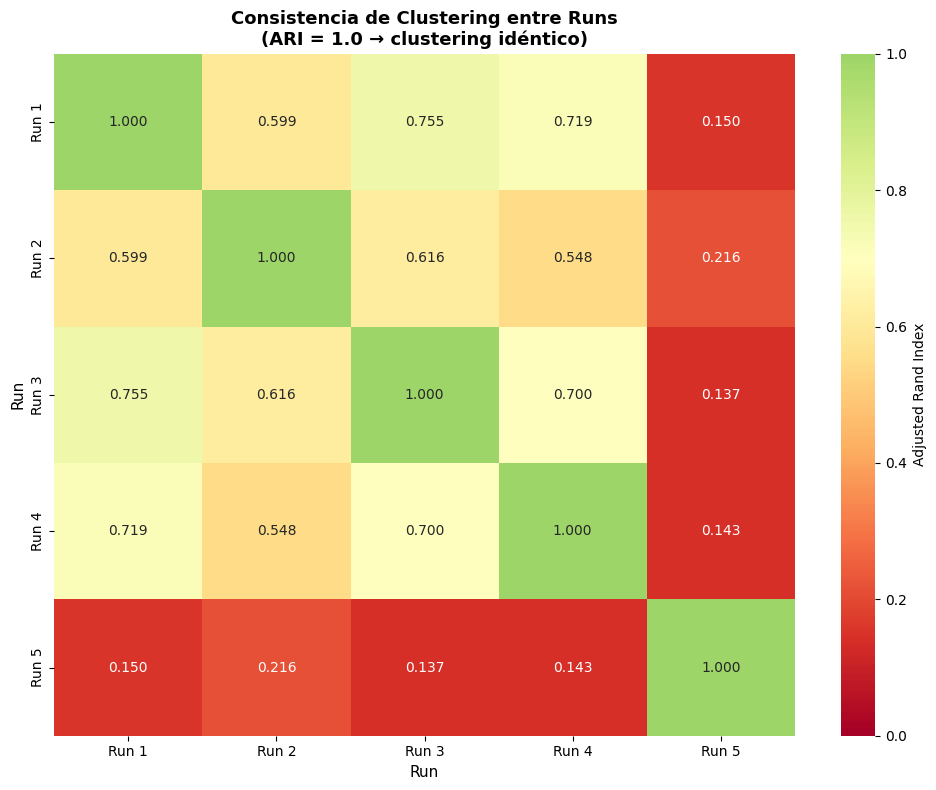

In [14]:
print("ANÁLISIS DE CONSISTENCIA DE CLUSTERING")
print("="*80)

# Matriz de ARI entre runs
ari_matrix = np.zeros((n_runs, n_runs))

for i in range(n_runs):
    for j in range(n_runs):
        labels_i = RUNS_RESULTS[i]['labels_base']
        labels_j = RUNS_RESULTS[j]['labels_base']
        ari_matrix[i, j] = adjusted_rand_score(labels_i, labels_j)

# Estadísticas (excluyendo diagonal)
ari_offdiag = ari_matrix[mask]

print("\n1. ADJUSTED RAND INDEX (ARI) entre clustering de runs:")
print(f"  Media: {ari_offdiag.mean():.4f}")
print(f"  Std: {ari_offdiag.std():.4f}")
print(f"  Min: {ari_offdiag.min():.4f}")
print(f"  Max: {ari_offdiag.max():.4f}")

print("\n2. INTERPRETACIÓN:")
if ari_offdiag.mean() > 0.70:
    print(f"  ✓ CLUSTERING CONSISTENTE: ARI = {ari_offdiag.mean():.3f} > 0.70")
    print("    → Las estructuras de clusters son similares entre runs")
elif ari_offdiag.mean() > 0.50:
    print(f"  ≈ CLUSTERING MODERADO: ARI = {ari_offdiag.mean():.3f} (0.50-0.70)")
    print("    → Algunas diferencias en asignación de píxeles")
else:
    print(f"  ✗ CLUSTERING INESTABLE: ARI = {ari_offdiag.mean():.3f} < 0.50")
    print("    → Alta variabilidad en la estructura de clusters")

# Visualizar matriz ARI
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ari_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, center=0.7, ax=ax,
            xticklabels=[f"Run {i+1}" for i in range(n_runs)],
            yticklabels=[f"Run {i+1}" for i in range(n_runs)],
            cbar_kws={'label': 'Adjusted Rand Index'})
ax.set_title('Consistencia de Clustering entre Runs\n(ARI = 1.0 → clustering idéntico)', 
            fontsize=13, fontweight='bold')
ax.set_xlabel('Run', fontsize=11)
ax.set_ylabel('Run', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "reproducibility_clustering_ari.png"), 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)

## 15. Resumen Ejecutivo de Reproducibilidad

In [15]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO: ANÁLISIS DE REPRODUCIBILIDAD DEL IRCT")
print("="*80)

print(f"\nConfiguración: {N_RUNS} entrenamientos VAE independientes, K={K_CLUSTERS}, {EPOCHS} epochs")

print("\n1. CORRELACIÓN DE VALORES IRCT:")
print(f"   Pearson (valores absolutos): {pearson_offdiag.mean():.4f} ± {pearson_offdiag.std():.4f}")
print(f"   Spearman (ranking): {spearman_offdiag.mean():.4f} ± {spearman_offdiag.std():.4f}")

print("\n2. VARIABILIDAD ESPACIAL:")
print(f"   CV promedio por píxel: {100*irt_cv_per_pixel.mean():.2f}%")
print(f"   Std promedio del IRCT: {irt_std_per_pixel.mean():.2f}")

print("\n3. CONSISTENCIA DE CLUSTERING:")
print(f"   ARI promedio entre runs: {ari_offdiag.mean():.4f} ± {ari_offdiag.std():.4f}")

print("\n4. ESTADÍSTICAS DEL IRCT:")
print(f"   Media global: {irt_mean_per_pixel.mean():.2f} (±{irt_mean_per_pixel.std():.2f} std territorial)")
print(f"   Rango: [{irt_mean_per_pixel.min():.2f}, {irt_mean_per_pixel.max():.2f}]")

print("\n5. EVALUACIÓN DE ROBUSTEZ:")

# Score de robustez (0-3)
robustness_score = 0

if pearson_offdiag.mean() > 0.80:
    robustness_score += 1
    print("   ✓ Valores IRCT altamente correlacionados (Pearson > 0.80)")
elif pearson_offdiag.mean() > 0.60:
    robustness_score += 0.5
    print("   ≈ Valores IRCT moderadamente correlacionados (Pearson 0.60-0.80)")
else:
    print("   ✗ Baja correlación de valores IRCT (Pearson < 0.60)")

if spearman_offdiag.mean() > 0.85:
    robustness_score += 1
    print("   ✓ Ranking de resiliencia consistente (Spearman > 0.85)")
elif spearman_offdiag.mean() > 0.70:
    robustness_score += 0.5
    print("   ≈ Ranking moderadamente consistente (Spearman 0.70-0.85)")
else:
    print("   ✗ Ranking inestable (Spearman < 0.70)")

if irt_cv_per_pixel.mean() < 0.15:
    robustness_score += 1
    print(f"   ✓ Baja variabilidad espacial (CV = {100*irt_cv_per_pixel.mean():.1f}% < 15%)")
elif irt_cv_per_pixel.mean() < 0.25:
    robustness_score += 0.5
    print(f"   ≈ Variabilidad espacial moderada (CV = {100*irt_cv_per_pixel.mean():.1f}% 15-25%)")
else:
    print(f"   ✗ Alta variabilidad espacial (CV = {100*irt_cv_per_pixel.mean():.1f}% > 25%)")

print(f"\n6. PUNTUACIÓN DE ROBUSTEZ: {robustness_score:.1f}/3.0")

if robustness_score >= 2.5:
    print("   ✓✓✓ MODELO ALTAMENTE ROBUSTO")
    print("   → El IRCT es confiable y reproducible para uso en tesis")
elif robustness_score >= 1.5:
    print("   ✓✓ MODELO MODERADAMENTE ROBUSTO")
    print("   → El IRCT es utilizable, considerar promediar múltiples runs")
else:
    print("   ✓ MODELO CON LIMITACIONES")
    print("   → Revisar hiperparámetros, aumentar epochs o usar ensemble")

print("\n" + "="*80)


RESUMEN EJECUTIVO: ANÁLISIS DE REPRODUCIBILIDAD DEL IRCT

Configuración: 5 entrenamientos VAE independientes, K=3, 200 epochs

1. CORRELACIÓN DE VALORES IRCT:
   Pearson (valores absolutos): 0.4774 ± 0.1426
   Spearman (ranking): 0.4457 ± 0.1462

2. VARIABILIDAD ESPACIAL:
   CV promedio por píxel: 26.34%
   Std promedio del IRCT: 9.62

3. CONSISTENCIA DE CLUSTERING:
   ARI promedio entre runs: 0.4583 ± 0.2497

4. ESTADÍSTICAS DEL IRCT:
   Media global: 40.95 (±12.07 std territorial)
   Rango: [4.37, 68.41]

5. EVALUACIÓN DE ROBUSTEZ:
   ✗ Baja correlación de valores IRCT (Pearson < 0.60)
   ✗ Ranking inestable (Spearman < 0.70)
   ✗ Alta variabilidad espacial (CV = 26.3% > 25%)

6. PUNTUACIÓN DE ROBUSTEZ: 0.0/3.0
   ✓ MODELO CON LIMITACIONES
   → Revisar hiperparámetros, aumentar epochs o usar ensemble



## 16. Exportar Resultados

In [16]:
# Guardar resultados en CSV
results_df = pd.DataFrame({
    'pixel_id': np.arange(n_spatial),
    'lat': coords_df['lat'].values,
    'lon': coords_df['lon'].values,
    'irt_mean': irt_mean_per_pixel,
    'irt_std': irt_std_per_pixel,
    'irt_cv': irt_cv_per_pixel,
    'irt_min': irt_matrix.min(axis=1),
    'irt_max': irt_matrix.max(axis=1),
})

# Agregar IRCT de cada run
for run_result in RUNS_RESULTS:
    run_id = run_result['run_id']
    results_df[f'irt_run{run_id}'] = run_result['irt_scores']

output_file = os.path.join(PLOTS_DIR, "reproducibility_irt_results.csv")
results_df.to_csv(output_file, index=False)
print(f"Resultados guardados en: {output_file}")

# Guardar métricas de correlación
metrics_df = pd.DataFrame({
    'metric': ['pearson_mean', 'pearson_std', 'spearman_mean', 'spearman_std', 
               'cv_mean', 'cv_std', 'ari_mean', 'ari_std', 'robustness_score'],
    'value': [
        pearson_offdiag.mean(),
        pearson_offdiag.std(),
        spearman_offdiag.mean(),
        spearman_offdiag.std(),
        irt_cv_per_pixel.mean(),
        irt_cv_per_pixel.std(),
        ari_offdiag.mean(),
        ari_offdiag.std(),
        robustness_score
    ]
})

metrics_file = os.path.join(PLOTS_DIR, "reproducibility_metrics_summary.csv")
metrics_df.to_csv(metrics_file, index=False)
print(f"Métricas de resumen guardadas en: {metrics_file}")

print(f"\n✓ Todos los resultados exportados a: {PLOTS_DIR}")

Resultados guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison/reproducibility_irt_results.csv
Métricas de resumen guardadas en: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison/reproducibility_metrics_summary.csv

✓ Todos los resultados exportados a: /home/aninotna/magister/tesis/justh2_pipeline/plots/resilience_comparison
